In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/train_aWnotuB_new.csv")
df.head()

,DateTime,Junction,Vehicles,ID,weekday,year,month,day,hour
0,2015-11-01 00:00:00,1,15,20151101001,Sunday,2015,11,1,0
1,2015-11-01 01:00:00,1,13,20151101011,Sunday,2015,11,1,1
2,2015-11-01 02:00:00,1,10,20151101021,Sunday,2015,11,1,2
3,2015-11-01 03:00:00,1,7,20151101031,Sunday,2015,11,1,3
4,2015-11-01 04:00:00,1,9,20151101041,Sunday,2015,11,1,4


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['weekday'] = le.fit_transform(df['weekday'])

In [4]:
X = df[
    [
        'Junction',
        'year',
        'month',
        'day',
        'hour',
        'weekday'
    ]
]

y = df['Vehicles']
print(X.shape)
print(y.shape)

(48120, 6)
(48120,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, pred_lr)

rmse = np.sqrt(
    mean_squared_error(y_test, pred_lr)
)

r2 = r2_score(y_test, pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 9.747014266829979
RMSE: 12.999304590353443
R2  : 0.5853680041721738


In [7]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=200,
random_state=42,
n_jobs=-1)

rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, pred_rf)

rmse = np.sqrt(
    mean_squared_error(y_test, pred_rf)
)

r2 = r2_score(y_test, pred_rf)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 2.402958229426434
RMSE: 3.5897695580705284
R2  : 0.9683804479567587


In [8]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

    Feature  Importance
0  Junction    0.517197
1      year    0.166177
4      hour    0.144679
5   weekday    0.071125
2     month    0.068127
3       day    0.032695


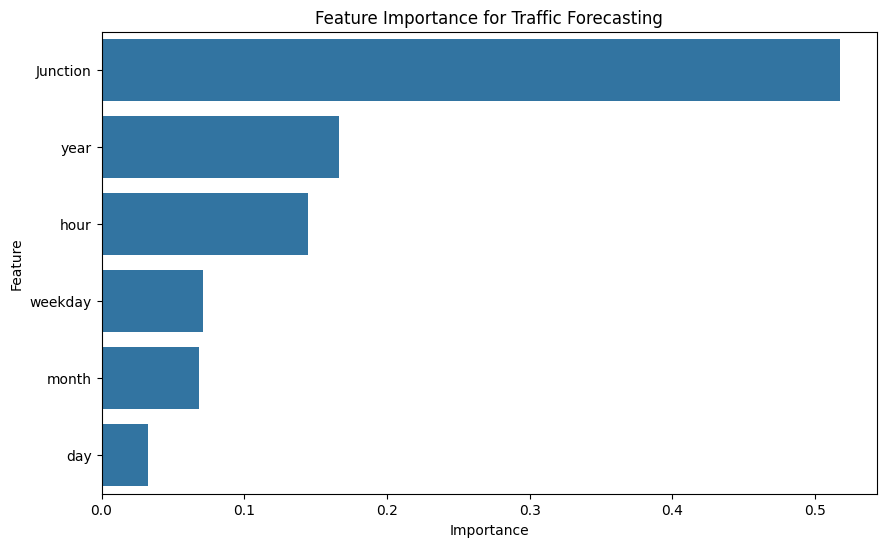

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance for Traffic Forecasting")

plt.show()

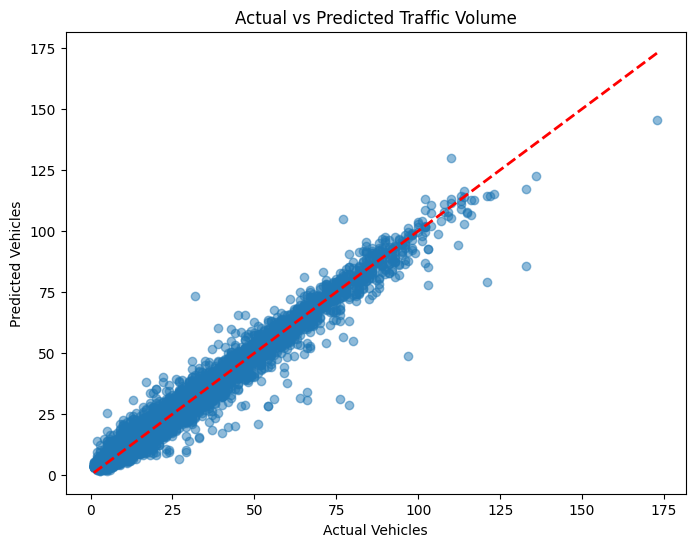

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")
plt.title("Actual vs Predicted Traffic Volume")

plt.show()

In [11]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, pred_xgb)

rmse = np.sqrt(
    mean_squared_error(y_test, pred_xgb)
)

r2 = r2_score(y_test, pred_xgb)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)